# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [4]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

c:\Users\sahil\anaconda\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [5]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [6]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

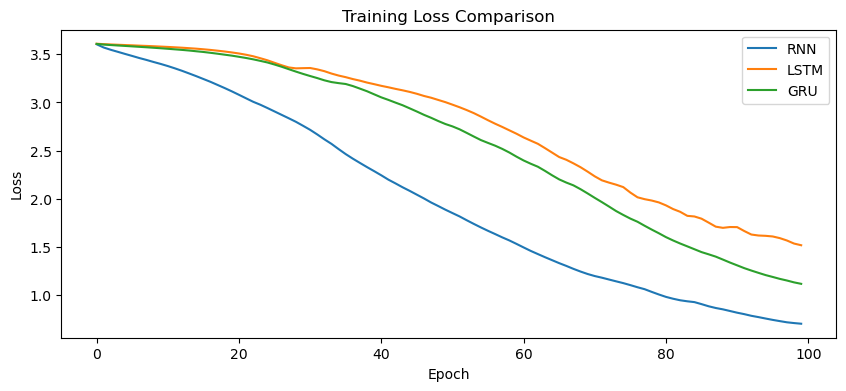

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [8]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [9]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning is transforming artificial intelligence sentences
LSTM: deep learning learning transforming artificial meaningful sentences
GRU : deep learning is transforming artificial intelligence intelligence


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

#  Completing the Student Learning Tasks
Below I have actually done all 5 beginner tasks listed above one by one.

## Task 1
I picked a small paragraph about machine learning basics and ran it through the same tokenization + sequence creation steps.

In [10]:
# my own paragraph (task 1)
my_corpus = '''
machine learning is a subset of artificial intelligence
it allows computers to learn from data without being explicitly programmed
neural networks are inspired by the human brain
deep learning uses multiple layers to extract features automatically
convolutional networks work well for images while recurrent networks work well for sequences
the more good quality data we have the better the model usually performs
'''
print(my_corpus)

# same tokenization steps as before but on my_corpus
tokenizer_t1 = Tokenizer()
tokenizer_t1.fit_on_texts([my_corpus])

total_words_t1 = len(tokenizer_t1.word_index) + 1
print("vocab size for my corpus:", total_words_t1)

sequences_t1 = []
for line in my_corpus.split('\n'):
    token_list = tokenizer_t1.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        sequences_t1.append(token_list[:i+1])

max_len_t1 = max(len(seq) for seq in sequences_t1)
sequences_t1 = pad_sequences(sequences_t1, maxlen=max_len_t1, padding='pre')

X_t1 = sequences_t1[:, :-1]
y_t1 = sequences_t1[:, -1]
print("X_t1 shape:", X_t1.shape)
print("y_t1 shape:", y_t1.shape)

# train a quick lstm on this new corpus so we can see it actually generates text from it
model_t1 = Sequential([
    Embedding(total_words_t1, 32, input_length=max_len_t1-1),
    LSTM(64),
    Dense(total_words_t1, activation='softmax')
])
model_t1.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model_t1.fit(X_t1, y_t1, epochs=100, verbose=0)
print("trained on my own corpus, done")


machine learning is a subset of artificial intelligence
it allows computers to learn from data without being explicitly programmed
neural networks are inspired by the human brain
deep learning uses multiple layers to extract features automatically
convolutional networks work well for images while recurrent networks work well for sequences
the more good quality data we have the better the model usually performs

vocab size for my corpus: 52
X_t1 shape: (56, 12)
y_t1 shape: (56,)
trained on my own corpus, done


## Task 2
Original models used embedding dimension 32. Here I bumped it up to 100 and trained an LSTM on the original corpus to compare.

In [11]:
# task 2 - bigger embedding dimension (32 -> 100), keeping everything else same as original lstm_model
lstm_bigembed_model = Sequential([
    Embedding(total_words, 100, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_bigembed_model.compile(loss='sparse_categorical_crossentropy',
                             optimizer='adam',
                             metrics=['accuracy'])

bigembed_history = lstm_bigembed_model.fit(X, y, epochs=100, verbose=0)
print("lstm with embedding dim 100 trained")
print("final loss with embed=32 :", lstm_history.history['loss'][-1])
print("final loss with embed=100:", bigembed_history.history['loss'][-1])

lstm with embedding dim 100 trained
final loss with embed=32 : 1.5151814222335815
final loss with embed=100: 1.0731453895568848


##  Task 3
Retrained the LSTM model for 200 epochs instead of 100 to see if loss keeps dropping.

trained for 200 epochs


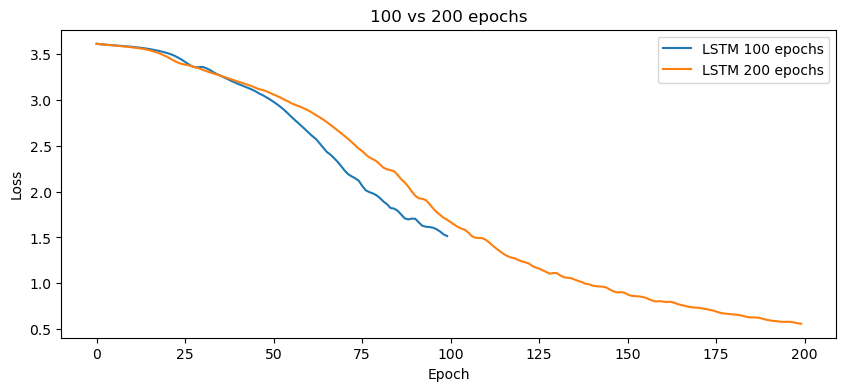

In [12]:
# task 3 - train for 200 epochs instead of 100
lstm_200_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_200_model.compile(loss='sparse_categorical_crossentropy',
                        optimizer='adam',
                        metrics=['accuracy'])

history_200 = lstm_200_model.fit(X, y, epochs=200, verbose=0)
print("trained for 200 epochs")

plt.figure(figsize=(10,4))
plt.plot(lstm_history.history['loss'], label='LSTM 100 epochs')
plt.plot(history_200.history['loss'], label='LSTM 200 epochs')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("100 vs 200 epochs")
plt.legend()
plt.show()

## Task 4
Same LSTM setup but with 128 hidden units instead of 64, to see if a bigger layer helps on this tiny dataset.

In [13]:
# task 4 - hidden units 64 -> 128
lstm_128_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_128_model.compile(loss='sparse_categorical_crossentropy',
                        optimizer='adam',
                        metrics=['accuracy'])

history_128 = lstm_128_model.fit(X, y, epochs=100, verbose=0)
print("final loss with 64 units :", lstm_history.history['loss'][-1])
print("final loss with 128 units:", history_128.history['loss'][-1])

final loss with 64 units : 1.5151814222335815
final loss with 128 units: 1.0213696956634521


## Task 5
Using the same generate_text function from before but with next_words=10.

In [14]:
# task 5 - generate 10 words instead of 5, reusing the same generate_text function
print("RNN :", generate_text(rnn_model, "deep learning", 10))
print("LSTM:", generate_text(lstm_model, "deep learning", 10))
print("GRU :", generate_text(gru_model, "deep learning", 10))

RNN : deep learning is transforming artificial intelligence sentences than lstm helps term sequential
LSTM: deep learning learning transforming artificial meaningful sentences sentences sentences for data data
GRU : deep learning is transforming artificial intelligence intelligence sentences sentences sentences sentences data


# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**